In [1]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from core.signal.preprocess import *
from glob import glob
import torchaudio
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.signal import *
import os
import torchinfo
import core.nn.dataset
import torchvision.transforms
from scipy.signal import savgol_filter

ModuleNotFoundError: No module named 'core.nn.dataset'

In [ ]:
import logging
# fix seed for reproducibility
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
logging.basicConfig(level=logging.INFO)
Fs = 16000
N = 200

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

vctkds = torchaudio.datasets.VCTK_092(root="vctk/", download=False)
ds2 = core.nn.dataset.VCTK_CSV("MICEMOUSE\gen\csv", Fs = Fs, device = device, resampleMethod='sinc')
paired_ds = core.nn.dataset.PairedAudioDataset(vctkds, ds2)
if os.path.exists("L.pt"):
    L = torch.load("L.pt")
else:
    L = []
    for A, B, _, _, _, _ in tqdm(paired_ds):
        Bs = B.shape[-1]
        As = A.shape[-1]
        L.append(Bs - As - 2 * Fs)
    L = torch.tensor(L, dtype=torch.float32)
    torch.save(L, "L.pt")
# remove outliers from L
time_threshold = 2 # seconds
idxx = torch.where(L < Fs * time_threshold)[0] # Mark outliers where the mouse track's length does not match the ground truth
filtered_paired_ds = torch.utils.data.Subset(paired_ds, idxx)
stat_subset = torch.utils.data.Subset(filtered_paired_ds, torch.randperm(len(filtered_paired_ds))[:N])
Lsubset = L[idxx]
print(f"Removed {len(L) - len(idxx)} outliers {100*(len(L) - len(idxx))/len(L):.2f}% of the dataset")
print(f"Remaining {len(paired_ds)} samples")
print(f"Using {len(stat_subset)} samples for statistics")
def trim_or_pad(x, T):
    if x.shape[-1] > T:
        return x[:T]
    else:
        # return F.pad(x, (0, T - x.shape[-1]))
        # pad at the beginning instead
        return F.pad(x, (T - x.shape[-1], 0))

def trim_or_pad2(x, T):
    if x.shape[-1] > T:
        return x[:, :T]
    else:
        return F.pad(x, (T - x.shape[-1], 0), mode="constant", value=0)

batch_size = 32
# Split into train, test, and dev
trainSplit = 0.85
testSplit = 0.125
devSplit = 0.025
assert trainSplit + testSplit + devSplit == 1
lenTrain = int(len(filtered_paired_ds) * trainSplit)
lenTest = int(len(filtered_paired_ds) * testSplit)
lenDev = len(filtered_paired_ds) - lenTrain - lenTest
# select lenTrain random indices
np.random.seed(0) # for reproducibility
idxtrain = np.random.choice(len(filtered_paired_ds), lenTrain, replace=False)
idxTest = np.setdiff1d(np.arange(len(filtered_paired_ds)), idxtrain)
idxtest = np.random.choice(idxTest, lenTest, replace=False)
idxdev = np.setdiff1d(idxTest, idxtest)
assert len(idxtrain) + len(idxtest) + len(idxdev) == len(filtered_paired_ds)

train = torch.utils.data.Subset(filtered_paired_ds, idxtrain)
test = torch.utils.data.Subset(filtered_paired_ds, idxtest)
dev = torch.utils.data.Subset(filtered_paired_ds, idxdev)

T = 5 * Fs
def collate(batch):
    N = len(batch)
    out_wavs = torch.zeros((N, T), device=device)
    out_mouse = torch.zeros((N, 2, T), device=device)
    i = 0
    for e in batch:
        out_wavs[i] = trim_or_pad(e[0].squeeze(), T).to(device)
        out_mouse[i] = trim_or_pad2(e[1].squeeze()[:, Fs:-Fs], T).to(device)
        i += 1
    return out_wavs, out_mouse


train_loader = torch.utils.data.DataLoader(train, batch_size=batch_size, shuffle=True, collate_fn=collate, num_workers=0)
test_loader = torch.utils.data.DataLoader(test, batch_size=batch_size, shuffle=False, collate_fn=collate, num_workers=0)
dev_loader = torch.utils.data.DataLoader(dev, batch_size=batch_size, shuffle=False, collate_fn=collate, num_workers=0)

INFO:root:Initializing PairedAudioDataset...


Removed 1387 outliers 3.16% of the dataset
Remaining 43873 samples
Using 200 samples for statistics


In [ ]:
_, Xnoise, Ynoise = processFromFile("vctk\\gen\\noise\\noise_2023-11-03_21-00-40.csv", method='sinc')
# Pad to closest 16000
Fs = 16000
T = 2 * Fs
noise = F.pad(Xnoise+Ynoise, (0, torch.ceil(torch.tensor(Xnoise.shape[0] % T))*T - Xnoise.shape[0]), "constant", 0)
noise = noise.reshape(-1, T)

In [ ]:
# compute FFT in dev set
Data_PSD = []
Noisy_PSD = []
for A, B in tqdm(dev_loader):
    A = A.squeeze()
    B = B.squeeze()
    # Pad to closest 16000
    A = A.reshape(-1, T)
    B = B.reshape(-1, 2, T)
    A = A.to(device)
    B = B.to(device)
    A = torch.fft.rfft(A)
    B = torch.fft.rfft(B)
    Data_PSD.append(A)
    Noisy_PSD.append(B)

100%|██████████| 34/34 [00:08<00:00,  3.82it/s]


In [ ]:
Data_PSD = torch.cat(Data_PSD, dim=0)
Noisy_PSD = torch.cat(Noisy_PSD, dim=0)

torch.Size([1063, 16001])

In [ ]:
avgData_PSD = Data_PSD.abs().mean(dim=0).cpu()
avgNoisy_PSD = Noisy_PSD.abs().mean(dim=0).cpu()
avgNoisy_PSD = avgNoisy_PSD.mean(dim=0)

In [ ]:
# Compute FFT
noiseFFT = torch.fft.rfft(noise, dim=1)
noiseFFT = torch.abs(noiseFFT)
noiseFFT = noiseFFT.mean(dim=0)
normNoiseFFT = noiseFFT/noiseFFT.max()
filteredNoise = torch.from_numpy(savgol_filter(normNoiseFFT, 10, 1))

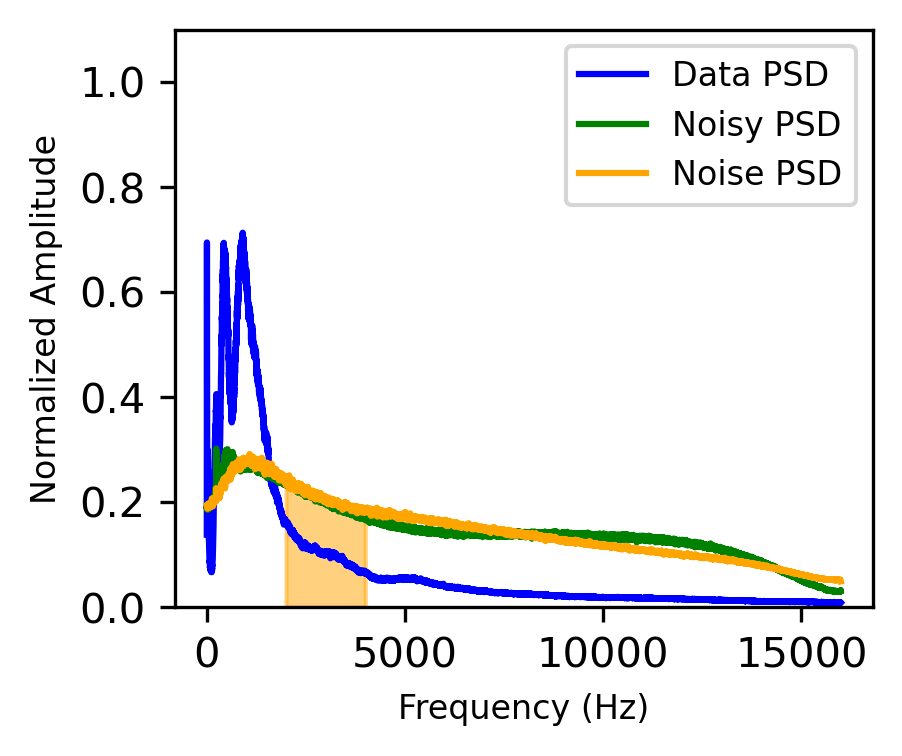

In [ ]:
plt.figure(figsize=(3, 2.5), dpi=300)
plt.plot(avgData_PSD/avgData_PSD.norm()/0.05, color='blue', label="Data PSD")
plt.plot(avgNoisy_PSD/avgNoisy_PSD.norm()/0.05, color='green', label="Noisy PSD")
plt.plot(filteredNoise/filteredNoise.norm()/0.05, color='orange', label="Noise PSD")
# plt.xlim(0, 4000)
plt.ylim(-0, 1.1)
# Shade under filterNoise above 2000 Hz
plt.fill_between(np.arange(2000, 4000), filteredNoise[2000:4000]/filteredNoise.norm()/0.05, alpha=0.5, color='orange')
plt.xlabel("Frequency (Hz)", fontsize=8)
plt.ylabel("Normalized Amplitude", fontsize=8)
plt.legend(fontsize=8)
# plt.savefig("figures/psd.svg", bbox_inches='tight')

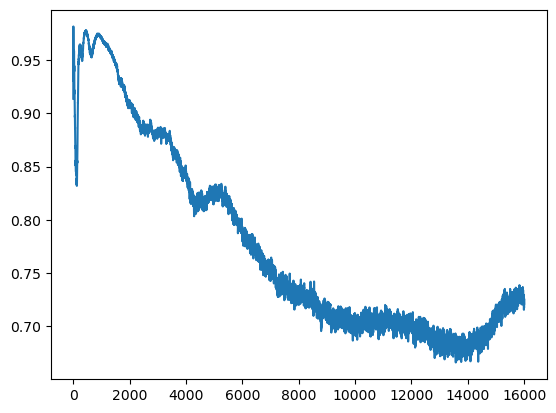

In [ ]:
H = avgData_PSD / (avgData_PSD + filteredNoise)
plt.plot(H)

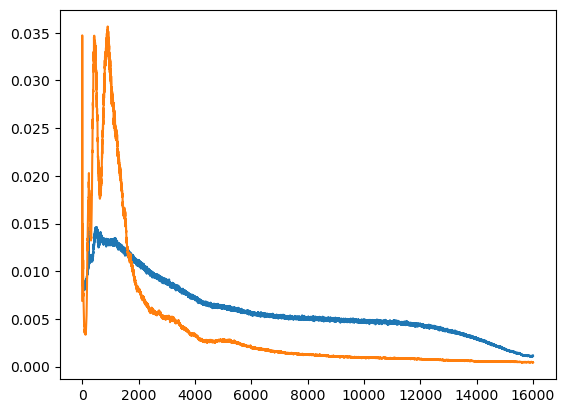

In [ ]:
plt.plot(H * avgNoisy_PSD / avgNoisy_PSD.norm())
plt.plot(avgData_PSD / avgData_PSD.norm())

In [ ]:
_, X, Y = processFromFile("plastic3.csv")
stft_fn = torchaudio.transforms.MelSpectrogram(
    sample_rate=16000,
    n_fft=1600,
    win_length=1600,
    hop_length=160,
    n_mels=80,
    f_min=1,
    f_max=4000,
    # power=2.0,
    normalized=True,
)
mel_bins = torch.linspace(stft_fn.mel_scale.f_min, stft_fn.mel_scale.f_max, stft_fn.mel_scale.n_mels)
freq_bins = 350 * (10**(mel_bins / 2595) - 1)

In [ ]:
F.mel_to_hz

AttributeError: module 'torch.nn.functional' has no attribute 'mel_to_hz'

In [ ]:
Xfft = torch.fft.rfft(Y)
Yfft = torch.fft.rfft(X)
Xp = torch.fft.irfft(F.pad(H, (0, Xfft.shape[-1] - H.shape[-1]), mode="constant", value=0) * Xfft)
Yp = torch.fft.irfft(F.pad(H, (0, Yfft.shape[-1] - H.shape[-1]), mode="constant", value=0) * Yfft)

In [ ]:
torch.save(H, "H.pt")

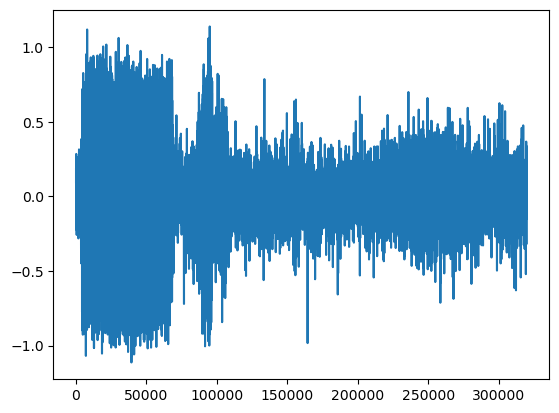

In [ ]:
plt.plot(Xp + Yp)

In [ ]:
torchaudio.save("plastic3.wav", torch.stack([Xp, Yp]), 16000)

In [ ]:
torchaudio.save("plastic3_before.wav", torch.stack([X, Y]), 16000)

In [ ]:
T = 4 * Fs
t = torch.linspace(0, T/Fs, T)
vol = 0.1
S = torch.sin(200 * 2 * np.pi * t)
d1 = torch.zeros(int(0.5 * Fs))
S2 = torch.sin((400 * t/4) * 2 * np.pi * t)
S3 = torch.sin((400 + 3600 * t/4) * 2 * np.pi * t)
S4 = torch.sin(400 * 2 * np.pi * t)
S = torch.cat((S, d1, S2, S3, S4), dim=0)

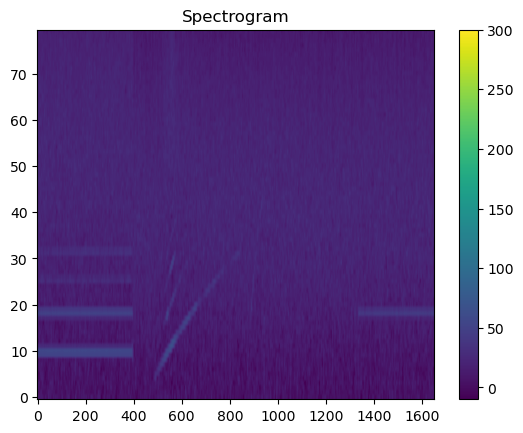

In [ ]:
_, X, Y = processFromFile("plastic3.csv")
i = 30
plot_spectrogram(stft_fn(X)[:, i:i+1651] + stft_fn(Y)[:, i:i+1651])

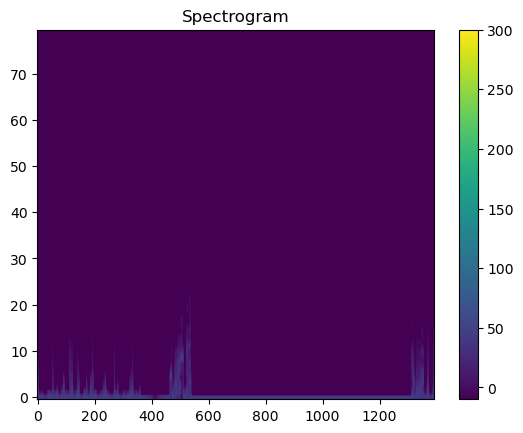

In [ ]:
_, X, Y = processFromFile("thin.csv")
i = 0
plot_spectrogram(stft_fn(X)[:, i:i+1651] + stft_fn(Y)[:, i:i+1651])

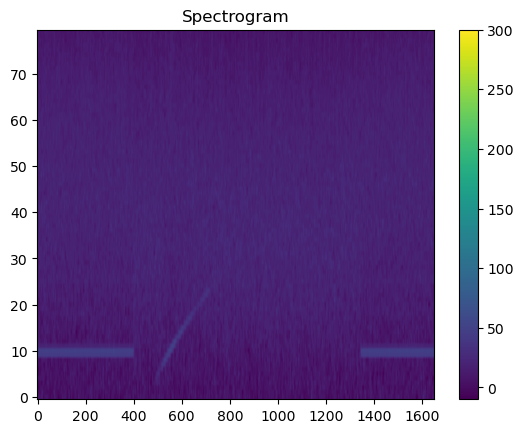

In [ ]:
_, X, Y = processFromFile("thick.csv")
i = 1050
plot_spectrogram(stft_fn(X)[:, i:i+1651] + stft_fn(Y)[:, i:i+1651])

In [ ]:
stft_fn(S).shape

torch.Size([80, 1651])

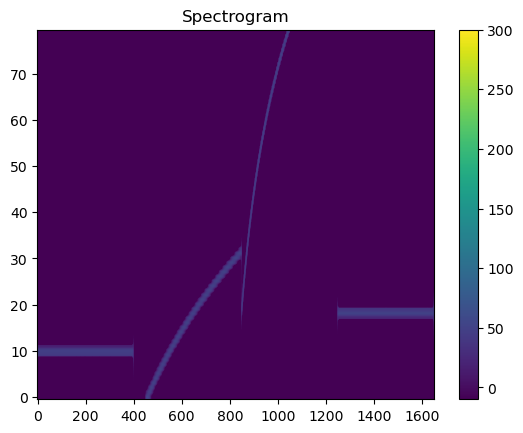

In [ ]:
plot_spectrogram(stft_fn(S))

In [ ]:
def plot_spectrogram(stft, title="Spectrogram", figax = None):
    magnitude = stft.abs()
    spectrogram = 20 * torch.log10(magnitude + 1e-8).numpy()
    if figax is None:
        figure, axis = plt.subplots(1, 1)
    else:
        figure, axis = figax
    img = axis.imshow(spectrogram, cmap="viridis", vmin=-10, vmax=300, origin="lower", aspect="auto")
    #
    axis.set_title(title, fontsize=8)
    # Make ticks smaller
    # axis.tick_params(axis='both', which='major', labelsize=1)
    # axis.tick_params(axis='both', which='minor', labelsize=1)
    # plt.colorbar(img, ax=axis)

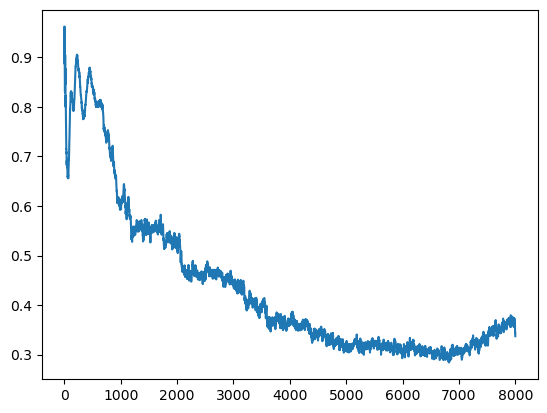

In [ ]:
plt.plot(H.cpu())

In [ ]:
freq_bins[-10]

tensor(15554.0771)

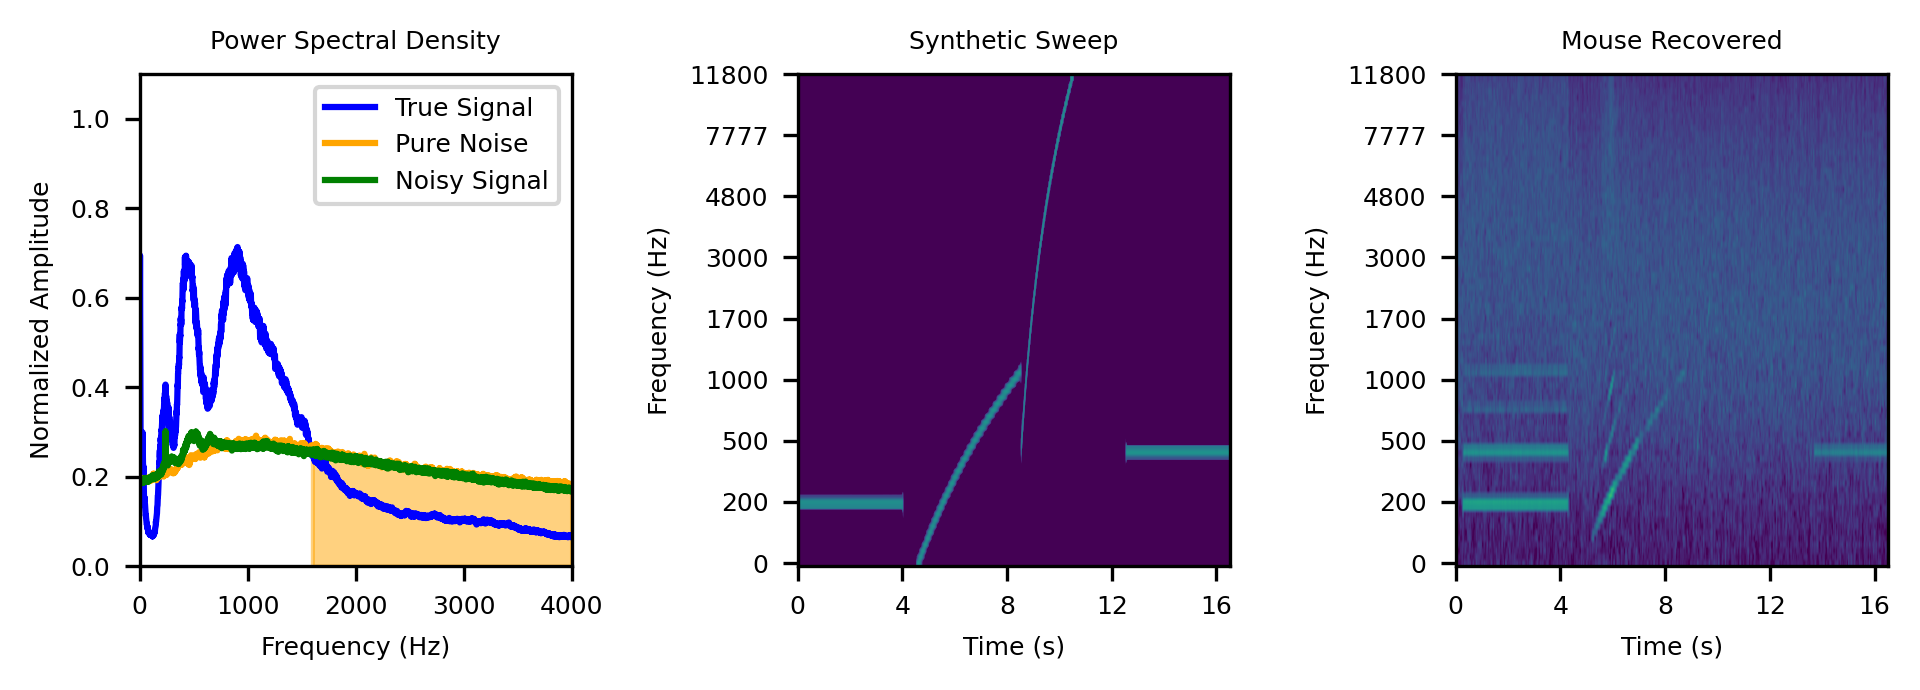

In [ ]:
# H = torch.load("H.pt").to(device)
H = H.to(device)
def apply_wiener(X):
    Xfft = torch.fft.rfft(X, dim=-1)
    Hpadded = F.pad(H, (0, Xfft.shape[-1] - H.shape[-1]), mode="constant", value=H.mean())
    Yfft = Xfft * Hpadded
    Y = torch.fft.irfft(Yfft, dim=-1)
    return Y
_, X, Y = processFromFile("plastic3.csv")
i = 0
fig, ax = plt.subplots(1, 3, figsize=(6.5, 2.4), dpi=300)
MS = stft_fn(X.cpu())[:, i:i+1651] + stft_fn(Y.cpu())[:, i:i+1651]
img = ax[2].imshow(60 * torch.log10(MS.abs() + 1e-8).numpy(), cmap="viridis", vmin=-10, vmax=300, origin="lower", aspect="auto")
ax[2].set_title("Mouse Recovered", fontsize=6)
# Set X and Y labels to seconds and Hz
ax[2].set_xlabel("Time (s)", fontsize=6)
ax[2].set_ylabel("Frequency (Hz)", fontsize=6)
ax[2].set_xticks([0, 400, 800, 1200, 1600])
ax[2].set_xticklabels([0, 4, 8, 12, 16])
ax[2].set_yticks([0, 10, 20, 30, 40, 50, 60, 70, 80])
ax[2].set_yticklabels([0, 200, 500, 1000, 1700, 3000, 4800, 7777, 11800])
ax[2].tick_params(axis='both', which='major', labelsize=6)
ax[2].tick_params(axis='both', which='minor', labelsize=6)

img = ax[1].imshow(60 * torch.log10(stft_fn(S).abs() + 1e-8).numpy(), cmap="viridis", vmin=-10, vmax=300, origin="lower", aspect="auto")
ax[1].set_title("Synthetic Sweep", fontsize=6)
# Set X and Y labels to seconds and Hz
ax[1].set_xlabel("Time (s)", fontsize=6)
ax[1].set_ylabel("Frequency (Hz)", fontsize=6)
ax[1].set_xticks([0, 400, 800, 1200, 1600])
ax[1].set_xticklabels([0, 4, 8, 12, 16])
ax[1].set_yticks([0, 10, 20, 30, 40, 50, 60, 70, 80])
ax[1].set_yticklabels([0, 200, 500, 1000, 1700, 3000, 4800, 7777, 11800])
ax[1].tick_params(axis='both', which='major', labelsize=6)
ax[1].tick_params(axis='both', which='minor', labelsize=6)

ax[0].plot(avgData_PSD/avgData_PSD.norm()/0.05, color='blue', label="True Signal")
ax[0].plot(filteredNoise/filteredNoise.norm()/0.05, color='orange', label="Pure Noise")
ax[0].plot(avgNoisy_PSD/avgNoisy_PSD.norm()/0.05, color='green', label="Noisy Signal")
ax[0].set_xlim(0, 4000)
ax[0].set_ylim(-0, 1.1)
# Shade under filterNoise above 2000 Hz
istart = 1600
ax[0].fill_between(np.arange(istart, 4000), filteredNoise[istart:4000]/filteredNoise.norm()/0.05, alpha=0.5, color='orange')
ax[0].set_xlabel("Frequency (Hz)", fontsize=6)
ax[0].set_ylabel("Normalized Amplitude", fontsize=6)
ax[0].legend(fontsize=6)
ax[0].tick_params(axis='both', which='major', labelsize=6)
ax[0].tick_params(axis='both', which='minor', labelsize=6)
ax[0].set_title("Power Spectral Density", fontsize=6)
fig.tight_layout()

fig.savefig("figures/PSDs.svg", bbox_inches='tight')

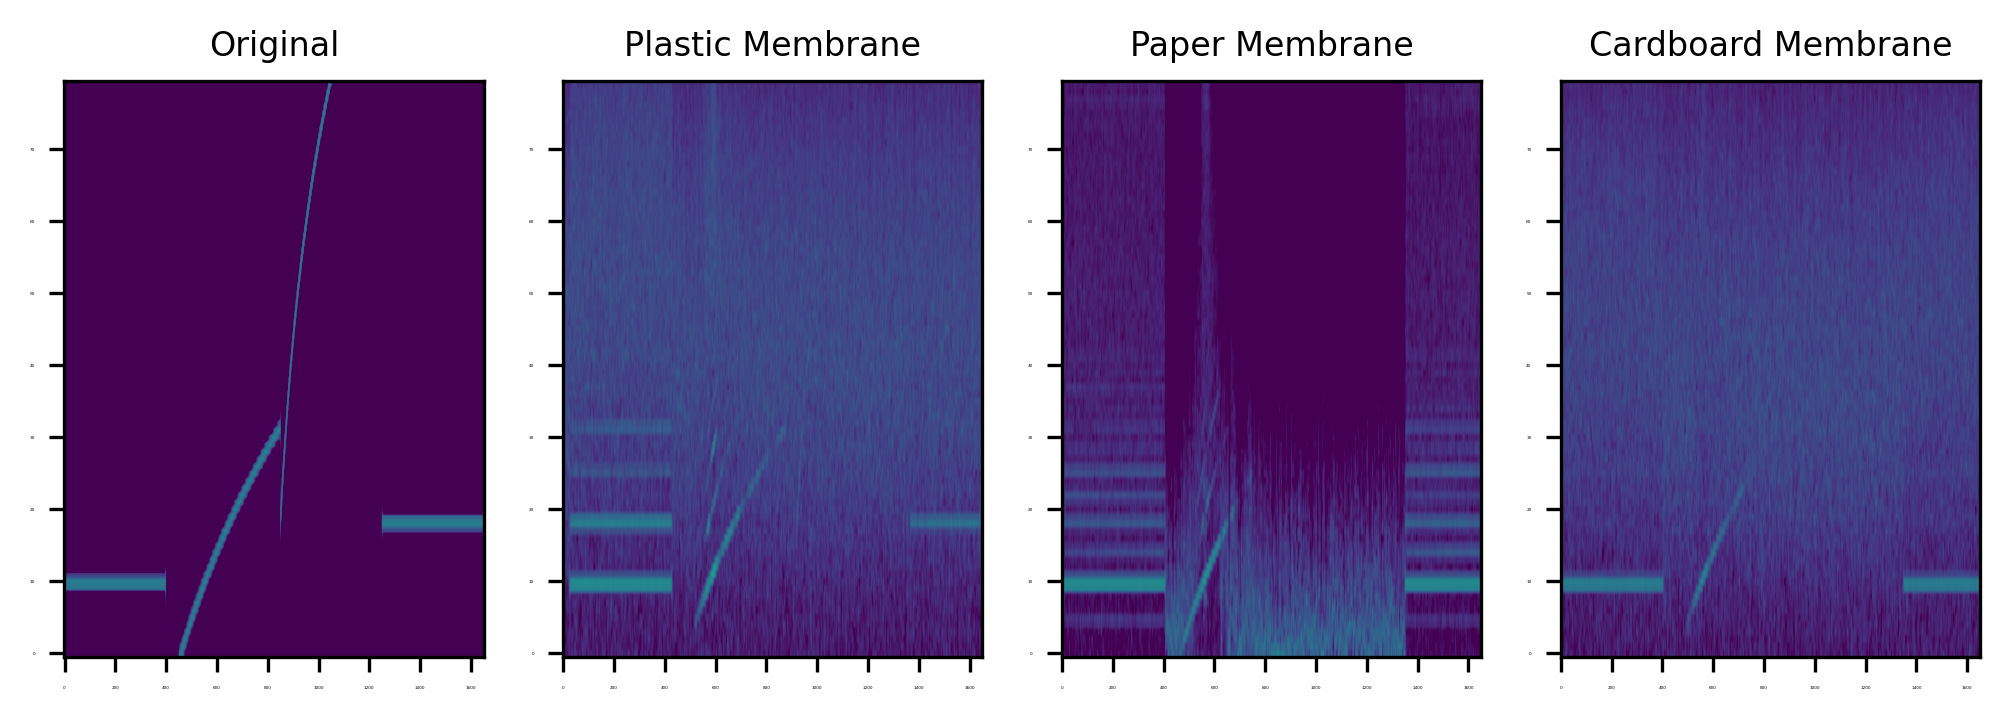

In [ ]:
fig, ax = plt.subplots(1, 4, figsize=(6.8, 2.5), dpi=300)
plot_spectrogram(stft_fn(S), "Original", (fig, ax[0]))
_, X, Y = processFromFile("plastic3.csv")
i = 0
plot_spectrogram(stft_fn(X)[:, i:i+1651] + stft_fn(Y)[:, i:i+1651], "Plastic Membrane", (fig, ax[1]))
_, X, Y = processFromFile("trans.csv")
i = 1600
plot_spectrogram(stft_fn(X)[:, i:i+1651] + stft_fn(Y)[:, i:i+1651], "Paper Membrane", (fig, ax[2]))
_, X, Y = processFromFile("thick.csv")
i = 1050
plot_spectrogram(stft_fn(X)[:, i:i+1651] + stft_fn(Y)[:, i:i+1651], "Cardboard Membrane", (fig, ax[3]))
plt.tight_layout()
plt.savefig("figures/FullMembranes.pdf", bbox_inches='tight')

(0.0, 4000.0)

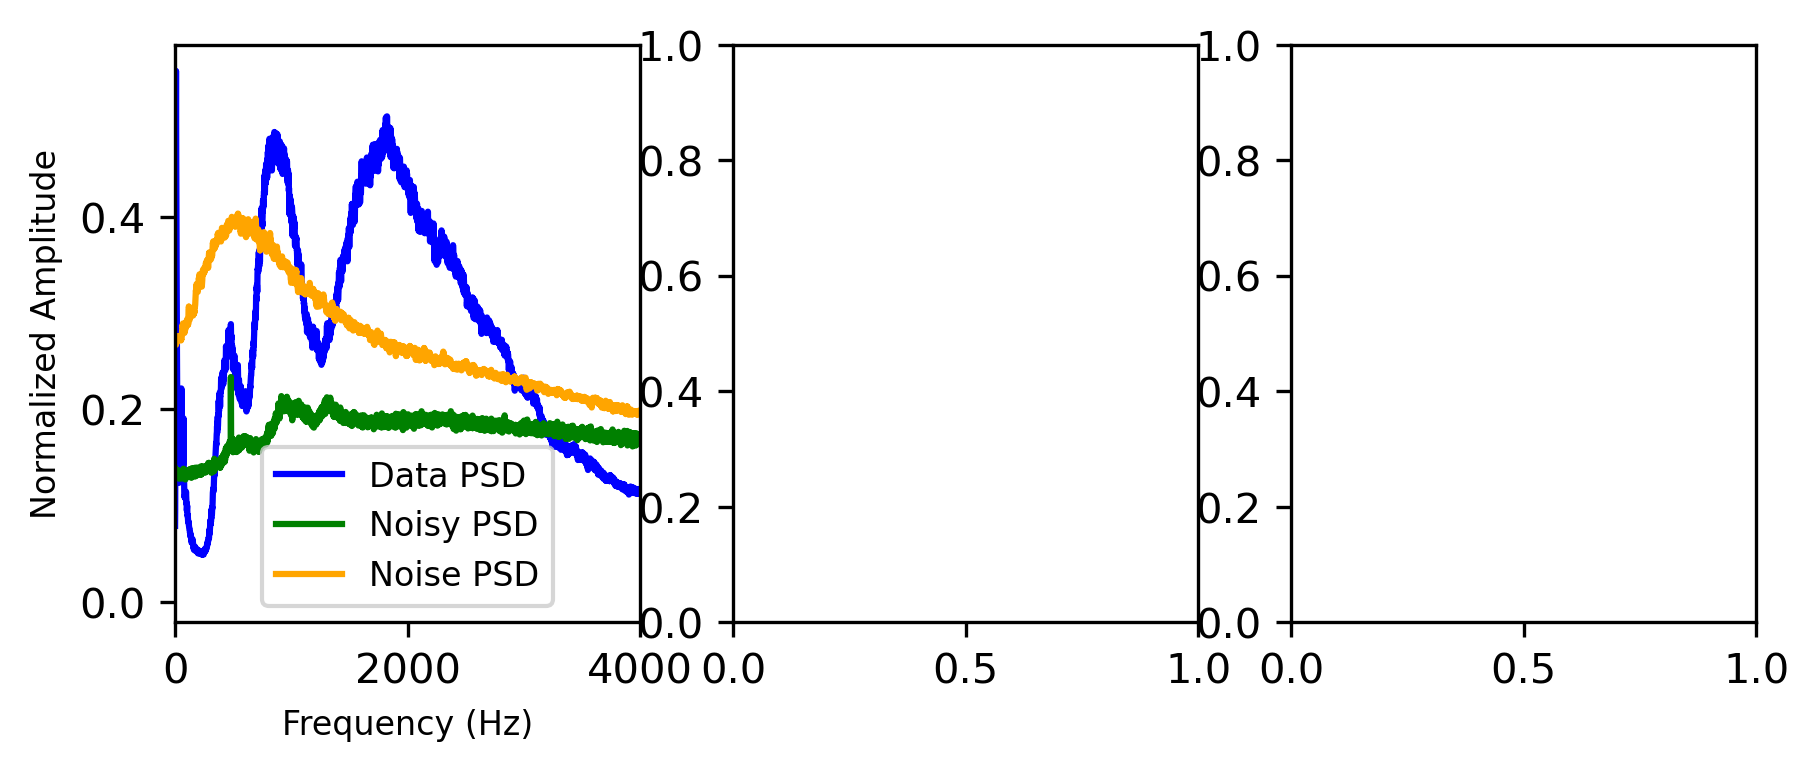

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(6.8, 2.5), dpi=300)
ax[0].plot(avgData_PSD/avgData_PSD.norm()/0.05, color='blue', label="Data PSD")
ax[0].plot(avgNoisy_PSD/avgNoisy_PSD.norm()/0.05, color='green', label="Noisy PSD")
ax[0].plot(filteredNoise/filteredNoise.norm()/0.05, color='orange', label="Noise PSD")
# plt.xlim(0, 4000)
# plt.ylim(-0, 1.1)
ax[0].set_xlabel("Frequency (Hz)", fontsize=8)
ax[0].set_ylabel("Normalized Amplitude", fontsize=8)
ax[0].legend(fontsize=8)
ax[0].set_xlim(0, 4000)
# Shade under filterNoise above 2000 Hz
# plt.fill_between(np.arange(2000, 4000), filteredNoise[2000:4000]/filteredNoise.norm()/0.05, alpha=0.5, color='orange')
# plt.xlabel("Frequency (Hz)", fontsize=8)
# plt.ylabel("Normalized Amplitude", fontsize=8)
# plt.legend(fontsize=8)